In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Credit Card Customer Data.xlsx to Credit Card Customer Data.xlsx


In [7]:
df = pd.read_excel("Credit Card Customer Data.xlsx")

In [8]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [9]:
df.shape

(660, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [11]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [12]:
df.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


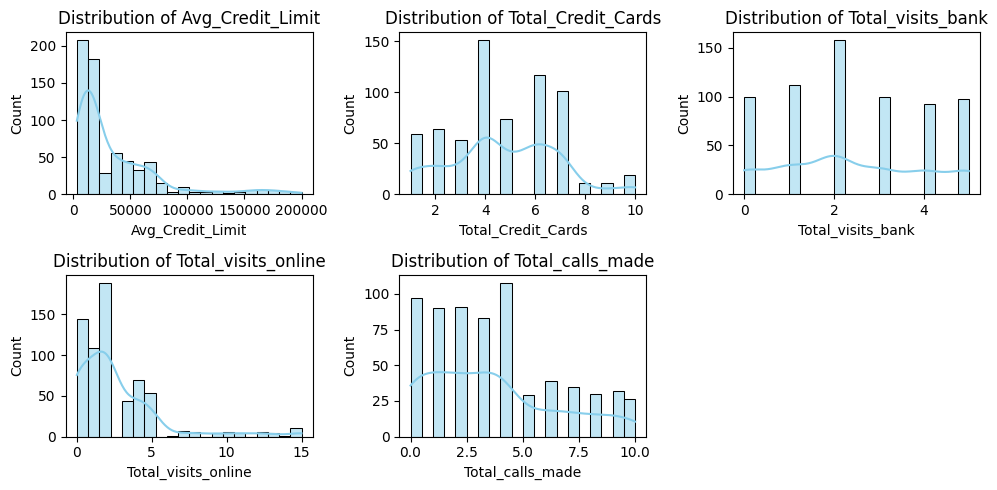

In [14]:
# Drop ID columns for analysis
cols = ['Avg_Credit_Limit', 'Total_Credit_Cards',
        'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

plt.figure(figsize=(10, 5))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

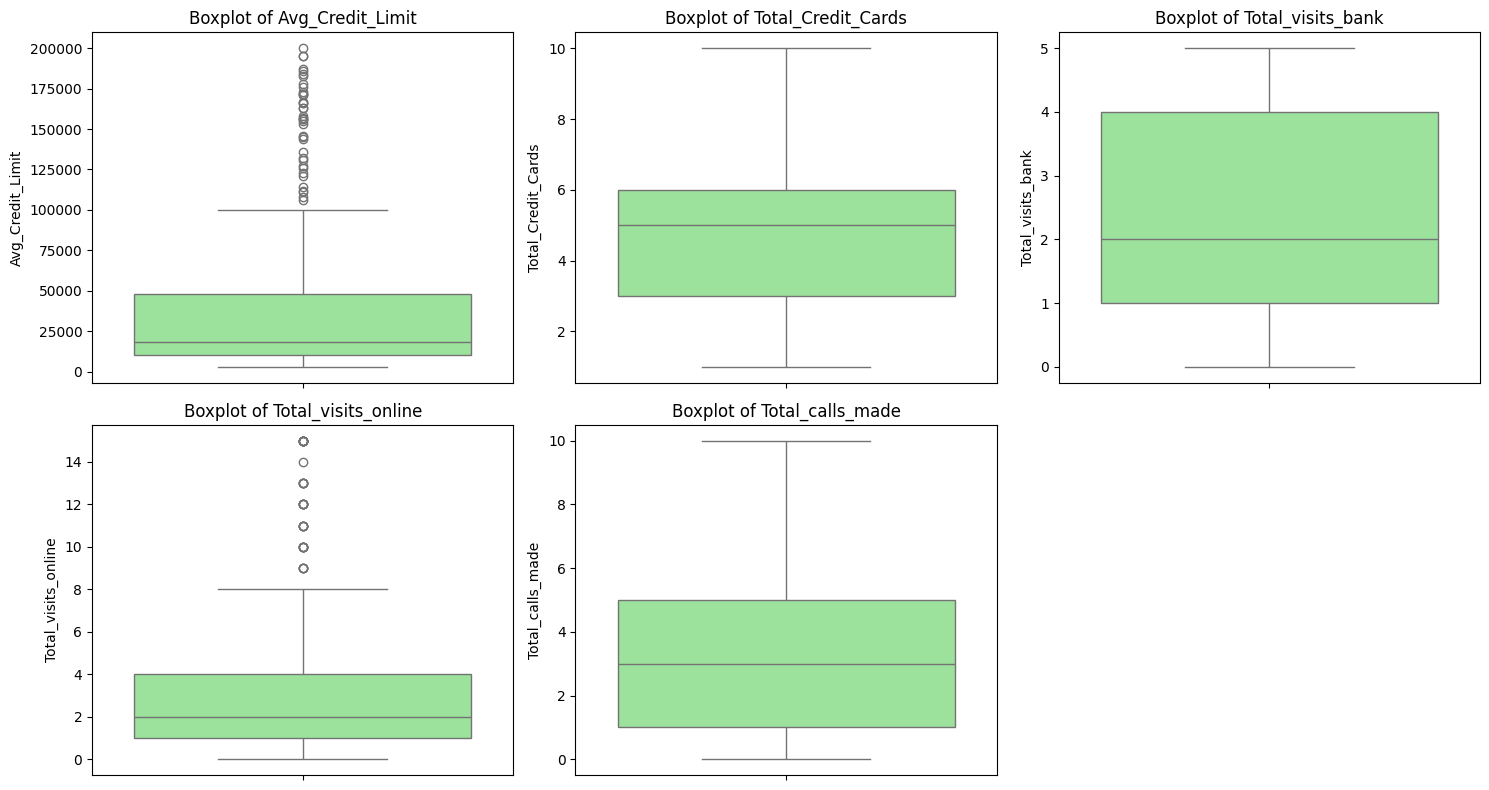

In [15]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}', fontsize=12)

plt.tight_layout()
plt.show()


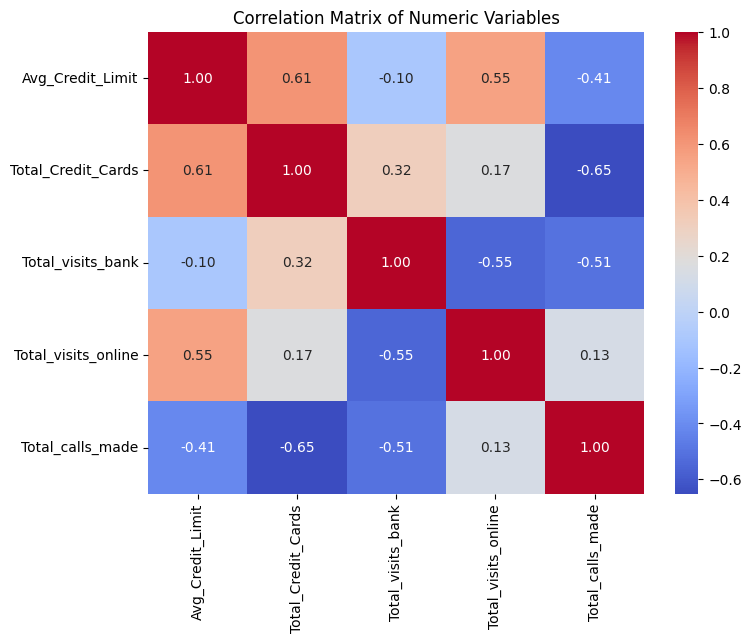

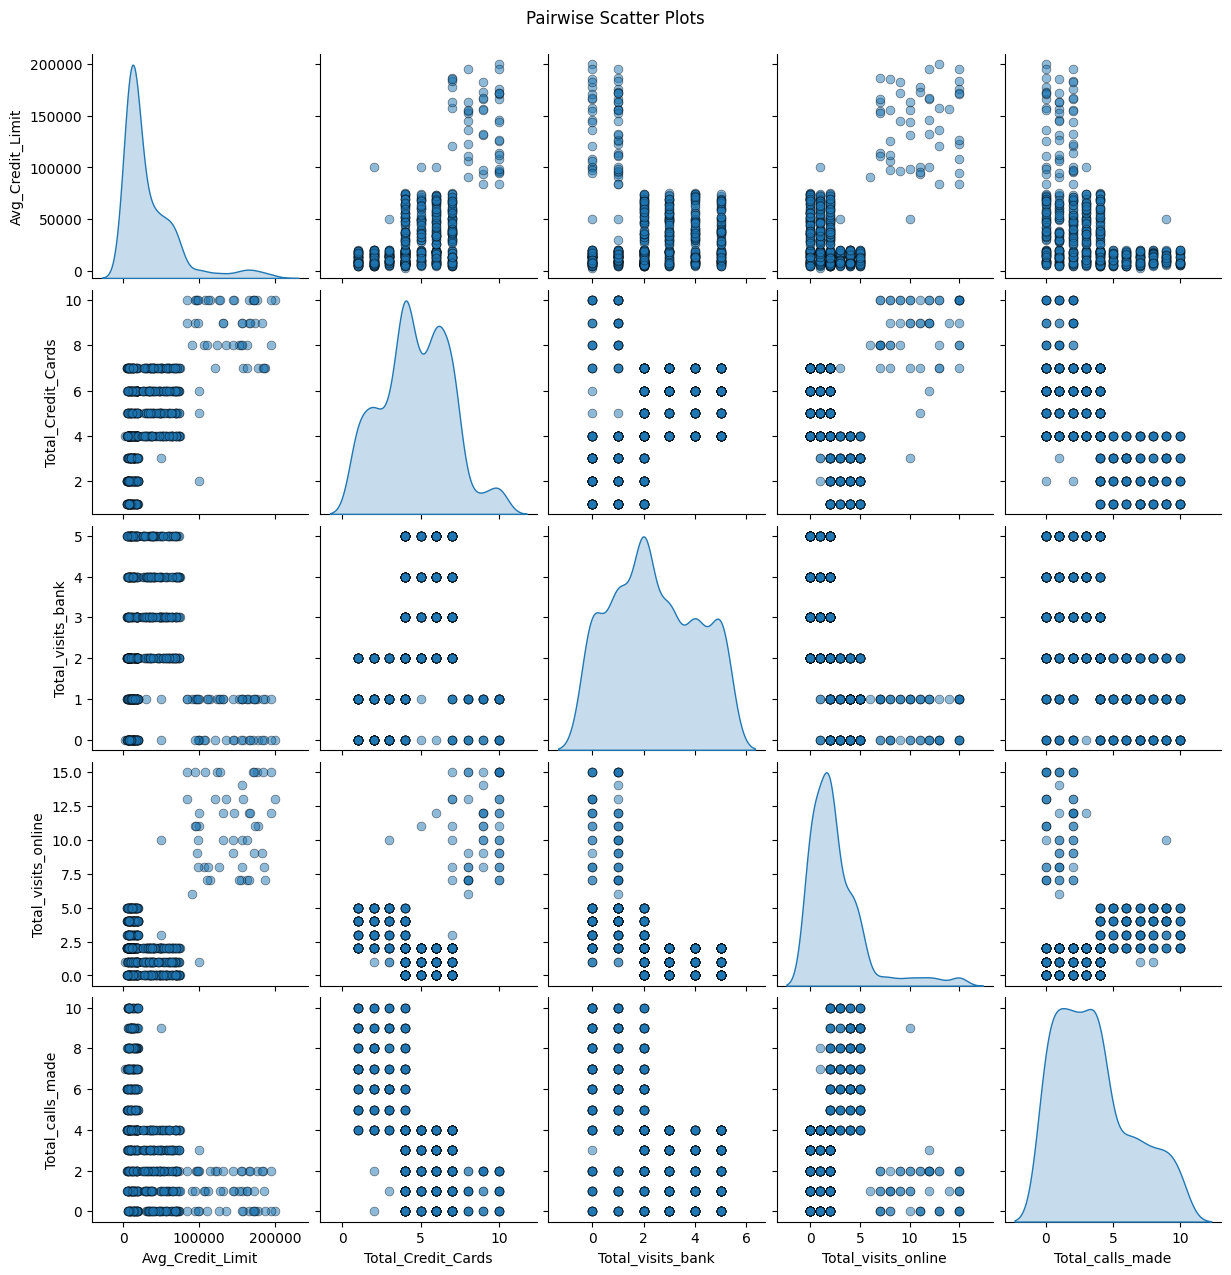

In [18]:
# Step 5: Bivariate Analysis

# Correct numeric columns based on your dataset
numeric_cols = ['Avg_Credit_Limit', 'Total_Credit_Cards',
                'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

# 1. Correlation matrix
plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

# 2. Pairwise scatter plots
sns.pairplot(df[numeric_cols], diag_kind='kde', plot_kws={'alpha':0.5, 's':40, 'edgecolor':'k'})
plt.suptitle("Pairwise Scatter Plots", y=1.02)
plt.show()


In [19]:
df_preprocessed = df.drop(['Sl_No', 'Customer Key'], axis=1)
df_preprocessed.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


In [20]:
# Step 2: Check for missing values
print(df_preprocessed.isnull().sum())

Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64


In [21]:
# Step 3: Outlier Detection and Treatment using IQR method
df_out = df_preprocessed.copy()  # Make a copy for outlier treatment

for col in df_out.columns:
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap the values at the lower and upper limits
    df_out[col] = np.where(df_out[col] < lower_limit, lower_limit,
                           np.where(df_out[col] > upper_limit, upper_limit, df_out[col]))

# Check first 5 rows after outlier treatment
df_out.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000.0,2.0,1.0,1.0,0.0
1,50000.0,3.0,0.0,8.5,9.0
2,50000.0,7.0,1.0,3.0,4.0
3,30000.0,5.0,1.0,1.0,4.0
4,100000.0,6.0,0.0,8.5,3.0


In [22]:
# Step 4: Feature Engineering
df_out['Credit_Utilization'] = df_out['Avg_Credit_Limit'] / df_out['Total_Credit_Cards']
df_out['Bank_Interaction'] = df_out['Total_visits_bank'] + df_out['Total_calls_made']

# Check the first 5 rows after feature engineering
df_out.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Credit_Utilization,Bank_Interaction
0,100000.0,2.0,1.0,1.0,0.0,50000.000000,1.0
1,50000.0,3.0,0.0,8.5,9.0,16666.666667,9.0
2,50000.0,7.0,1.0,3.0,4.0,7142.857143,5.0
3,30000.0,5.0,1.0,1.0,4.0,6000.000000,5.0
4,100000.0,6.0,0.0,8.5,3.0,16666.666667,3.0


In [23]:
# Step 5: Data Scaling
from sklearn.preprocessing import StandardScaler

# Select all numeric columns for clustering
features = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank',
            'Total_visits_online', 'Total_calls_made', 'Credit_Utilization', 'Bank_Interaction']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_out[features])

# Convert back to DataFrame for easy reference
df_scaled = pd.DataFrame(df_scaled, columns=features)
df_scaled.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Credit_Utilization,Bank_Interaction
0,2.398942,-1.249225,-0.860451,-0.619767,-1.251537,8.936352,-2.013705
1,0.643619,-0.787585,-1.473731,2.705813,1.891859,2.031639,1.217034
2,0.643619,1.058973,-0.860451,0.267054,0.145528,0.058864,-0.398335
3,-0.058511,0.135694,-0.860451,-0.619767,0.145528,-0.177869,-0.398335
4,2.398942,0.597334,-1.473731,2.705813,-0.203739,2.031639,-1.206020


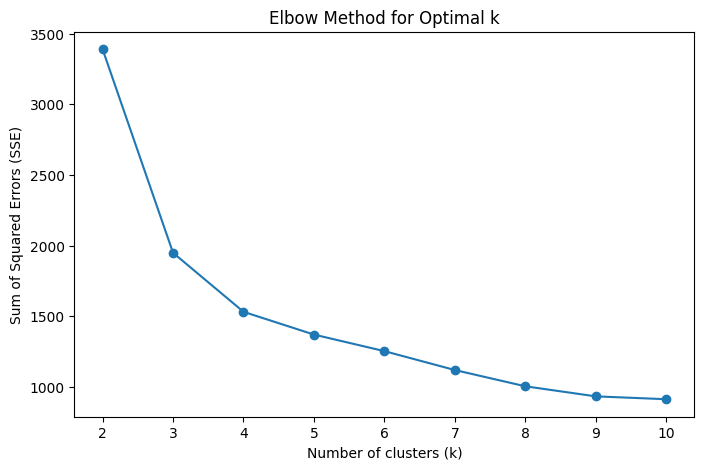

In [24]:
# Step 6a: Elbow Method to find optimal k
from sklearn.cluster import KMeans

sse = []
K_range = range(2, 11)  # Trying k from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    sse.append(kmeans.inertia_)

# Plot SSE vs k
plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [25]:
from sklearn.metrics import silhouette_score

# Set optimal number of clusters based on Elbow method
k_optimal = 3  # change this according to your Elbow plot

# Fit K-means
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)

# Add cluster labels to original dataframe
df_out['KMeans_Cluster'] = kmeans_labels

# Silhouette Score
sil_score = silhouette_score(df_scaled, kmeans_labels)
print(f'Silhouette Score for k={k_optimal}: {sil_score:.3f}')

Silhouette Score for k=3: 0.427


In [26]:
# Cluster profiling: Mean values of features per cluster
cluster_profile = df_out.groupby('KMeans_Cluster').mean().round(2)
cluster_profile


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Credit_Utilization,Bank_Interaction
KMeans_Cluster,,,,,,,
0,33493.54,5.51,3.48,0.98,2.01,6324.52,5.49
1,102607.84,8.61,0.61,8.04,1.06,12791.99,1.67
2,12184.68,2.40,0.93,3.57,6.91,6426.80,7.84


Cophenetic Correlation (single linkage): 0.671


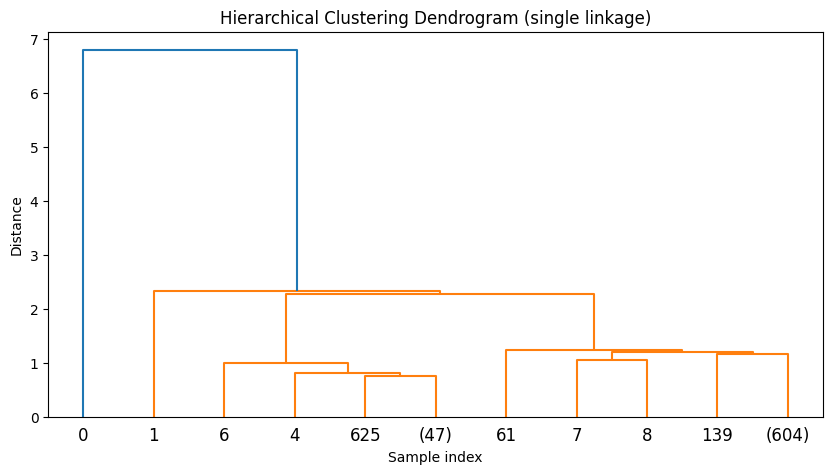

Cophenetic Correlation (complete linkage): 0.794


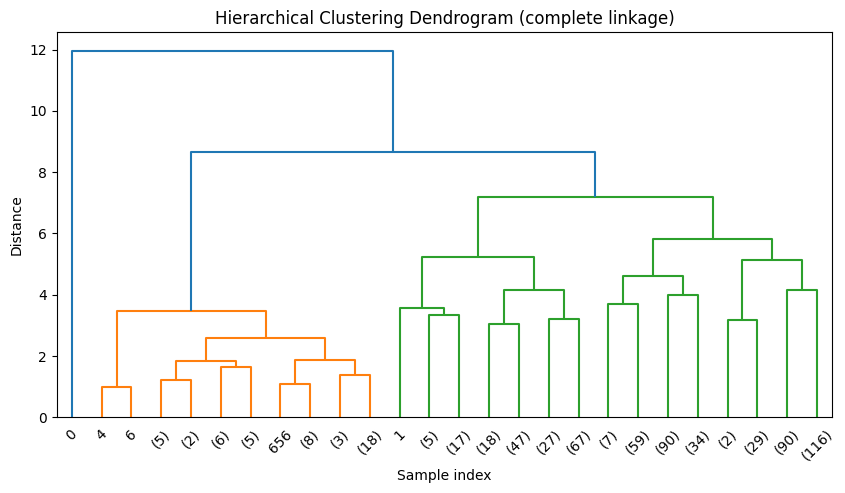

Cophenetic Correlation (average linkage): 0.850


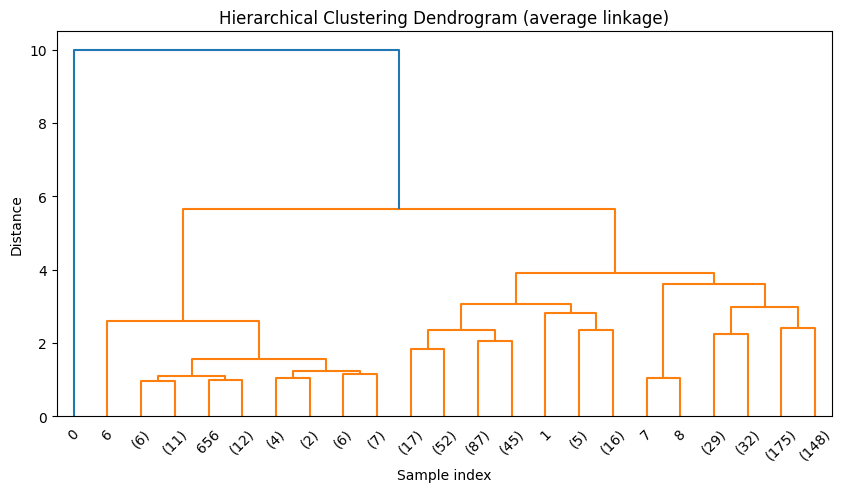

Cophenetic Correlation (ward linkage): 0.677


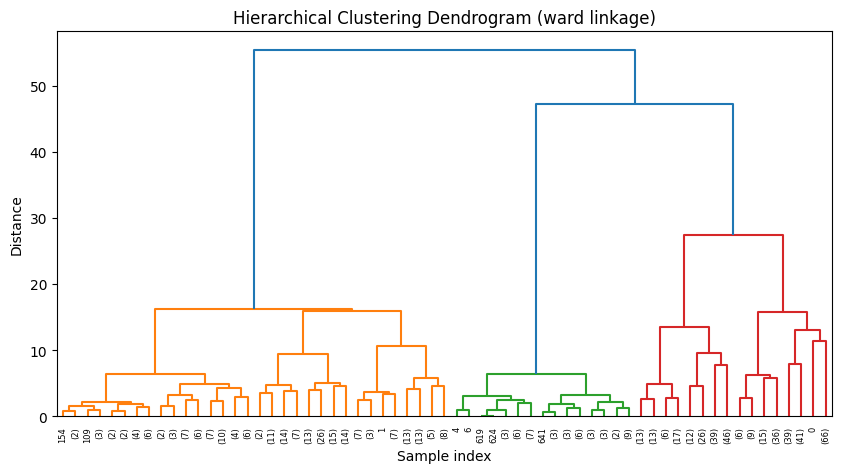

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

linkage_methods = ['single', 'complete', 'average', 'ward']

for method in linkage_methods:
    # Compute linkage matrix
    Z = linkage(df_scaled, method=method)

    # Compute cophenetic correlation
    c, coph_dists = cophenet(Z, pdist(df_scaled))
    print(f'Cophenetic Correlation ({method} linkage): {c:.3f}')

    # Plot dendrogram
    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='level', p=5, color_threshold=None)
    plt.title(f'Hierarchical Clustering Dendrogram ({method} linkage)')
    plt.xlabel('Sample index')
    plt.ylabel('Distance')
    plt.show()

In [28]:
from scipy.cluster.hierarchy import fcluster

# Fit Hierarchical clustering using average linkage
Z_avg = linkage(df_scaled, method='average')

# Assign cluster labels (choose k=3 clusters)
hier_labels = fcluster(Z_avg, t=3, criterion='maxclust')

# Add labels to original dataframe
df_out['Hier_Cluster'] = hier_labels - 1  # subtract 1 to make clusters start at 0

# Cluster profiling
hier_cluster_profile = df_out.groupby('Hier_Cluster').mean().round(2)
hier_cluster_profile


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Credit_Utilization,Bank_Interaction,KMeans_Cluster
Hier_Cluster,,,,,,,,
0,102660.00,8.74,0.60,8.18,1.08,12047.83,1.68,1.00
1,25725.78,4.38,2.55,1.93,3.79,6361.81,6.35,0.73
2,100000.00,2.00,1.00,1.00,0.00,50000.00,1.00,1.00
